In [1]:
%matplotlib inline

from glob import glob

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

In [2]:
LABELS = {
#    'ky.matc'       : 'Entropy-Optimal Sampler',
#    'ky.enc'        : 'Entropy-Optimal Sampler',
 #   'rej.binary'    : 'Rejection Sampler (Dyadic; Binary Search)',
  #  'rej.table'     : 'Rejection Sampler (Dyadic; Lookup Table)',
   # 'rej.matc'      : 'Rejection Sampler (Dyadic; New Method)',
    'rej.enc'       : 'Fast Loaded Dice Roller (FLDR)',
    #'rej.uniform'   : 'Rejection Sampler (Uniform)',
    #'interval'      : 'Exact Interval Sampler',
    'boost.alias'   : 'Alias Sampler',
    'std.inversion' : 'Inversion Sampler',
    'alias.exact'   : 'Exact Alias Sampler',
    'alias.integers' : 'Alias Integers',
    'aldr'          : 'ALDR',
    'alias.rust'    : 'Alias Rust',
}

In [3]:
def get_entropy(fname):
    with open(fname, 'r') as f:
        data = f.readlines()
        return float(data[-1])

In [4]:
# Penser à changer le n, le Z et le type de distribution en fonction du dossier que l'on veut charger
dist_type = 'very-biased'
n = 6
Z = 11420
seed = 2
# Changer ici le format du nom des distributions pour charger celles que l'on souhaite
pattern = 'dists.custom.%s.%d.%d.%d-work' % (dist_type, n, Z, seed)
f_runtimes = sorted(glob('../%s/*.runtimes' % (pattern,)))
f_sizes = sorted(glob('../%s/*.sizes' % (pattern,)))
f_dists = sorted(glob('../%s/*.dist' % (pattern,)))
runtimes = np.asarray([np.loadtxt(f) for f in f_runtimes])
sizes = np.asarray([np.loadtxt(f) for f in f_sizes])
entropies = np.asarray([get_entropy(f) for f in f_dists])
num_samples = 1e6
rates = runtimes / num_samples
samplers = [x.split('/')[-1].replace('.runtimes', '') for x in f_runtimes]

In [5]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

#### Plot Memory--Rate

In [6]:
selection = [
    'rej.enc',
    #'ky.enc',
    #'rej.binary',
    #'rej.uniform',
    #'rej.table',
    #'interval',
    'alias.exact',
    'alias.integers',
    'aldr',
    'alias.rust',
]

In [7]:
samplers

['aldr', 'alias.exact', 'alias.integers', 'alias.rust', 'rej.enc']

In [8]:
def run_plot_rate_size(samplers, rates, sizes):
    fig, ax = plt.subplots()
    collections = []
    
    for sampler, rate, size in zip(samplers, rates, sizes):
        if sampler not in selection:
            continue
        print(sampler)
        sc = ax.scatter(rate, size, label=LABELS[sampler], s=10, marker='.', alpha=1)
        collections.append((sampler, sc))

    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)

    ax.set_xlabel('Sampler Runtime (Seconds per Sample)', fontsize=14)
    ax.set_ylabel('Sampler Memory (Bytes)', fontsize=14)

    ax.xaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=100))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.xaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11, 20)*.1, numticks=24))

    ax.yaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=20))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11,20)*.1, numticks=100))

    fig.set_size_inches((8, 6))
    fig.set_facecolor('white')
    fig.set_tight_layout(True)
    
    return fig, ax, collections

aldr
alias.exact
alias.integers
alias.rust
rej.enc


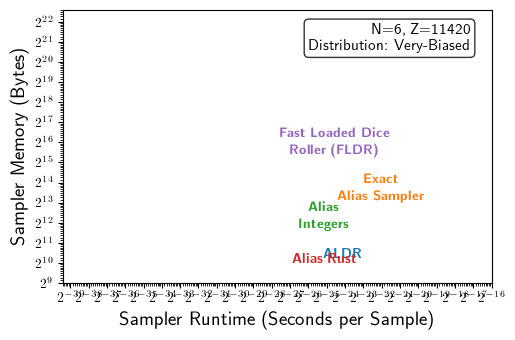

In [9]:
fig, ax, collections = run_plot_rate_size(samplers, rates, sizes)

# Create a mapping of sampler names to colors
sampler_colors = {sampler: sc.get_facecolors()[0] for sampler, sc in collections}

ax.set_xlim([1.5*2**-27, 2**-16])
ax.set_ylim([2**9, 1.5*2**22])

# Add legend for N, Z, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: {dist_type.title()}'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add labels with matching colors
ax.text(
    0.95*2**-22, 2**14,
    r'\begin{center}\textbf{Exact}\\\textbf{Alias Sampler}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.exact'])
ax.text(
    0.7*2**-24, 1.2*2**16,
    r'\begin{center}\textbf{Fast Loaded Dice}\\\textbf{Roller (FLDR)}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['rej.enc'])
ax.text(
    0.9*2**-25, 1.5*2**12,
    r'\begin{center}\textbf{Alias}\\\textbf{Integers}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.integers'])
ax.text(
    0.9*2**-24, 1.2*2**10,
    r'\begin{center}\textbf{ALDR}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['aldr'])
ax.text(
    0.9*2**-25, 2**10,
    r'\begin{center}\textbf{Alias Rust}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.rust'])
fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-sampler-comparison-runtime-memory.%s' % (ext,))

#### Plot Entropy--Rate

In [10]:
from scipy.signal import savgol_filter

In [11]:
def run_plot_entropy_rate(samplers, entropies, rate):
    fig, ax = plt.subplots()

    for sampler, rate in zip(samplers, rates):
        if sampler not in selection:
            continue
        print(sampler, len(entropies), len(rate))
        # yhat = savgol_filter(rate, 21, 3) # window size 51, polynomial order 3
        yhat = rate
        sc = ax.scatter([], [], label=r'\textbf{%s}' %(LABELS[sampler],), marker='.', s=50)
        c = sc.get_facecolors()[0]
        ax.scatter(entropies, yhat, color=c, marker='.', s=2)

    ax.set_yscale('log', basey=2)
    ax.set_xlabel('Entropy of Target Distribution', fontsize=14)
    ax.set_ylabel('Sampler Runtime (Seconds per Sample)', fontsize=12)

    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11, 20)*.1, numticks=24))
    ax.yaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=12))

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(.25))
    ax.legend(loc='upper left', bbox_to_anchor=(1,1))

    fig.set_tight_layout(True)
    fig.set_facecolor('white')
    fig.set_size_inches((8, 6))
    
    return fig, ax

In [12]:
for dist_type in distribution_types:
    sample_data = data_by_type[dist_type]
    rates_dist = sample_data['runtimes'] / num_samples
    entropies_dist = sample_data['entropies']
    samplers_dist = sample_data['samplers']
    
    fig, ax = run_plot_entropy_rate(samplers_dist, entropies_dist, rates_dist)

    # ax.set_xlim([0, 10.25])
    ax.set_ylim([2**-28, 2**-16])

    handles, labels = ax.get_legend_handles_labels()
    order = [6, 1, 3, 5, 0, 4, 2]
    if len(order) > len(handles):
        order = list(range(len(handles)))
    ax.legend(
        [handles[idx] for idx in order if idx < len(handles)],
        [labels[idx] for idx in order if idx < len(handles)],
        loc='upper left',
        framealpha=0,
        labelspacing=0,
        handletextpad=.5,
        handlelength=.5,
    )

    # Add distribution type to title
    ax.text(0.5, 1.05, f'Distribution Type: {dist_type.title()}', 
            transform=ax.transAxes, ha='center', va='bottom', fontsize=12, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    fig.set_tight_layout(True)
    fig.set_size_inches(5.25, 3.5)
    for ext in ['pdf', 'png']:
        fig.savefig(f'figure-4-sampler-comparison-entropy-runtime-{dist_type}.{ext}')

NameError: name 'distribution_types' is not defined